In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # 引入PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# 定义数据
n_samples = 1000

# 首先定义数据2个本质的主成分
# 生成 1000 个服从正态分布（均值为 0，标准差为 1）的随机浮点数
component1 = np.random.normal(0, 1, size=n_samples)
component2 = np.random.normal(0, 0.2, size=n_samples)

# 再定义噪声
noise = np.random.normal(0, 0.1, size=n_samples)

# 构造3维数据
X = np.vstack((component1 - component2, component1 + component2, component2 + noise)).T
print(X.shape)
print(X)

(1000, 3)
[[-2.69900355 -2.55713809  0.04870603]
 [-1.89460636 -1.61127021  0.14370958]
 [-0.07840432 -0.40692712 -0.13145178]
 ...
 [-0.28045865 -1.04040947 -0.34243149]
 [ 0.42903098  0.18349388 -0.174744  ]
 [-0.79359519 -1.0673251  -0.27488964]]


In [3]:
# 标准化
scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
print(X)

[[-2.69900355 -2.55713809  0.04870603]
 [-1.89460636 -1.61127021  0.14370958]
 [-0.07840432 -0.40692712 -0.13145178]
 ...
 [-0.28045865 -1.04040947 -0.34243149]
 [ 0.42903098  0.18349388 -0.174744  ]
 [-0.79359519 -1.0673251  -0.27488964]]


In [4]:
# 应用PCA，将3维数据提取主成分并降到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_stand)
print(X_pca.shape)
print(X_pca)

(1000, 2)
[[-3.6119835   0.29986898]
 [-2.4323401   0.71363909]
 [-0.42188641 -0.58195996]
 ...
 [-0.9946645  -1.54418616]
 [ 0.3125293  -0.76152622]
 [-1.35232913 -1.1729881 ]]


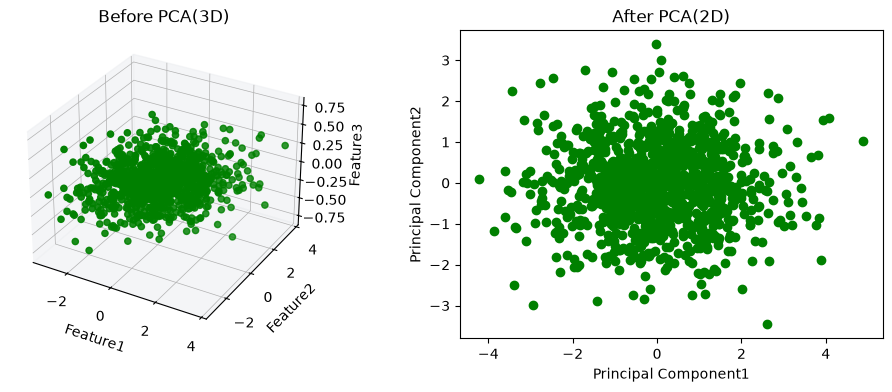

In [5]:
# 可视化
fig = plt.figure(figsize=(12, 4))

# 画出原始数据的3D分布图
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c='g')
ax1.set_title("Before PCA(3D)")
ax1.set_xlabel("Feature1")
ax1.set_ylabel("Feature2")
ax1.set_zlabel("Feature3")

# 画出降维之后的2D分布图
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c='g')
ax2.set_title("After PCA(2D)")
ax2.set_xlabel("Principal Component1")
ax2.set_ylabel("Principal Component2")

plt.show()